In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              ConfusionMatrixDisplay)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# **Section 2: Load the Dataset**

In [3]:
import kagglehub
import os

path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")
print("Path to dataset files:", path)

print(os.listdir(path))

100%|██████████| 8.56k/8.56k [00:00<00:00, 14.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/fedesoriano/heart-failure-prediction/versions/1
['heart.csv']


In [4]:
df = pd.read_csv(os.path.join(path, "heart.csv"))
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# **Section 3: Explore the Data (EDA)**

In [5]:
print("Shape:", df.shape)
df.info()

Shape: (918, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [6]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [7]:
print(df.isnull().sum())
print(df.duplicated().sum())

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64
0


HeartDisease
1    508
0    410
Name: count, dtype: int64


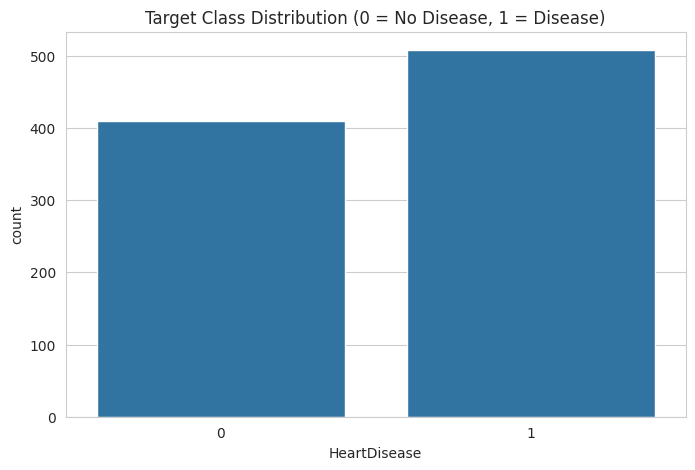

In [8]:
print(df["HeartDisease"].value_counts())
sns.countplot(x="HeartDisease", data=df)
plt.title("Target Class Distribution (0 = No Disease, 1 = Disease)")
plt.show()

In [9]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols.remove("HeartDisease")

print(categorical_cols)
print(numerical_cols)

['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']


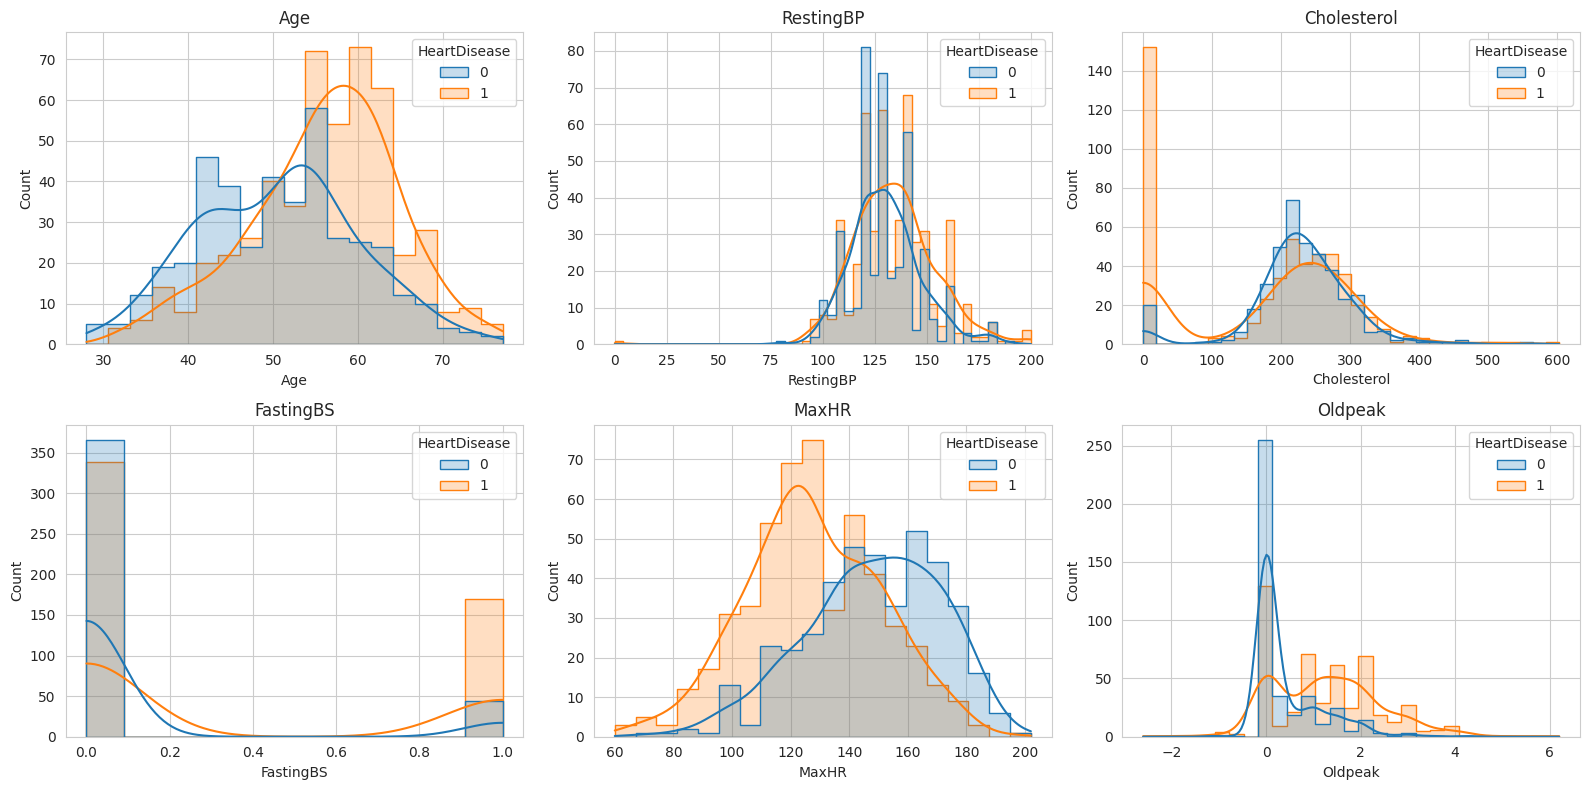

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.histplot(data=df, x=col, hue="HeartDisease", kde=True, ax=axes[i], element="step")
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

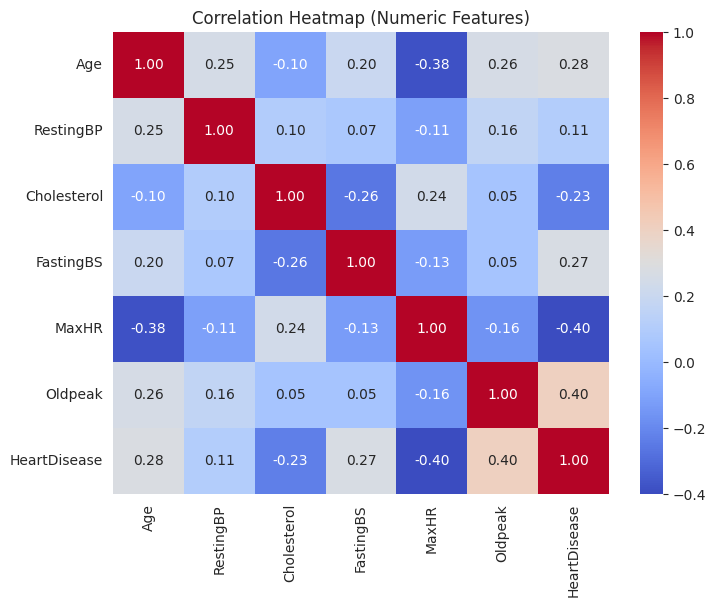

In [11]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[numerical_cols + ["HeartDisease"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

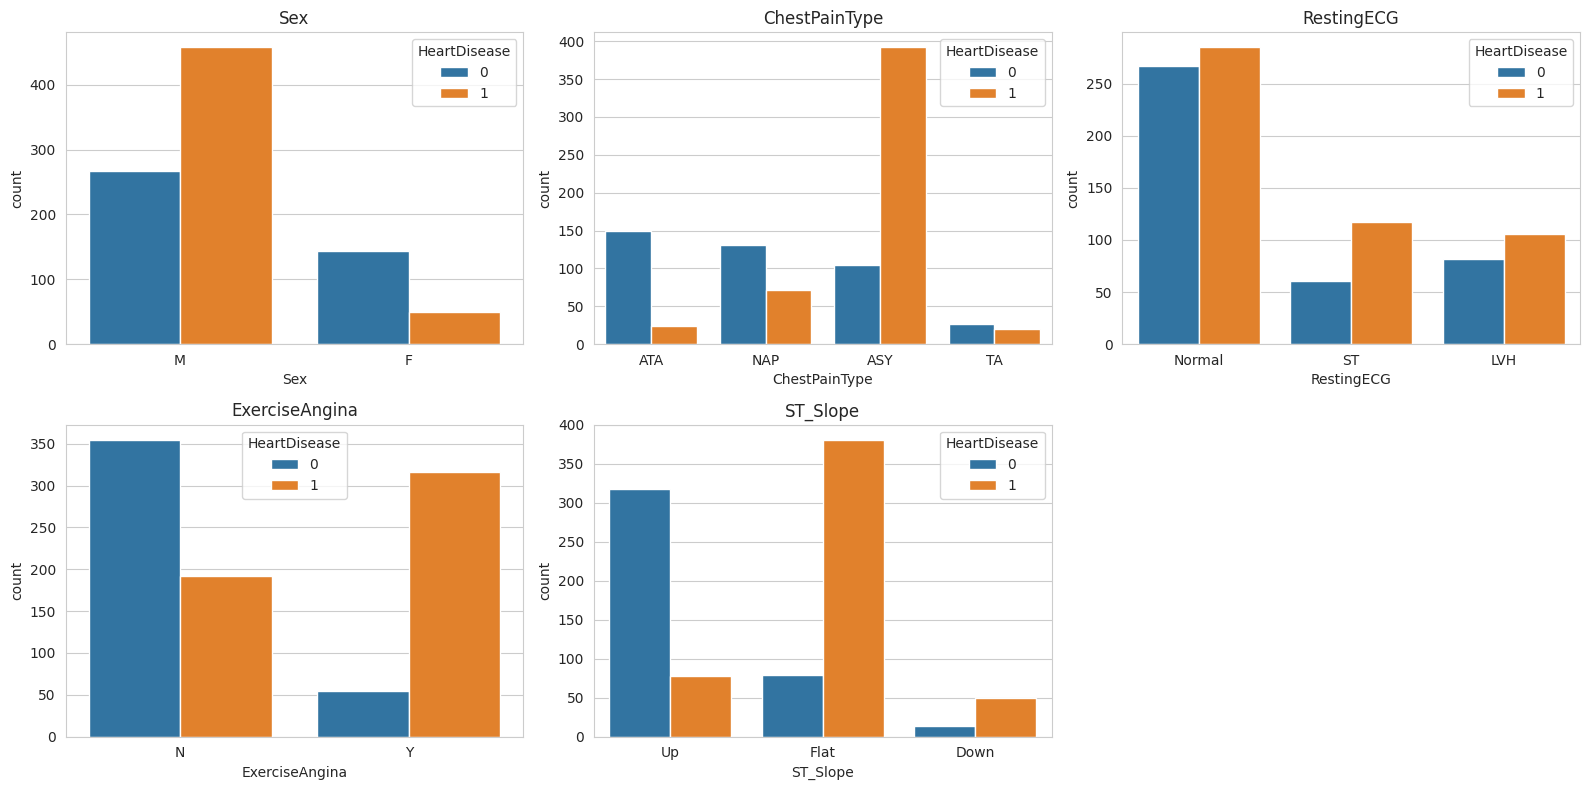

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, hue="HeartDisease", ax=axes[i])
    axes[i].set_title(col)
axes[-1].axis("off")
plt.tight_layout()
plt.show()

# **Section 4: Preprocessing**

In [13]:
data = df.copy()
data = data.drop_duplicates()

binary_cols = ["Sex", "ExerciseAngina"]
le = LabelEncoder()
for col in binary_cols:
    data[col] = le.fit_transform(data[col])
    print(col, list(le.classes_))

Sex ['F', 'M']
ExerciseAngina ['N', 'Y']


In [14]:
multi_class_cols = ["ChestPainType", "RestingECG", "ST_Slope"]
data = pd.get_dummies(data, columns=multi_class_cols, drop_first=True)

print(data.shape)
data.head()

(918, 16)


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0.0,0,True,False,False,True,False,False,True
1,49,0,160,180,0,156,0,1.0,1,False,True,False,True,False,True,False
2,37,1,130,283,0,98,0,0.0,0,True,False,False,False,True,False,True
3,48,0,138,214,0,108,1,1.5,1,False,False,False,True,False,True,False
4,54,1,150,195,0,122,0,0.0,0,False,True,False,True,False,False,True


In [15]:
X = data.drop("HeartDisease", axis=1)
y = data["HeartDisease"]
print(X.shape, y.shape)

(918, 15) (918,)


# **Section 5: Train/Test Split + Scaling**

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(X_train.shape, X_test.shape)

(734, 15) (184, 15)


In [17]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)
X_train_scaled.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
485,0.970012,0.51740,0.339016,0.127137,1.835497,-0.324520,1.202775,0.317046,2.096917,-0.5174,-0.240077,-1.247995,2.050774,0.981105,-0.862246
486,0.122028,0.51740,-1.266031,0.099443,1.835497,1.689837,-0.831411,-0.440356,2.096917,-0.5174,-0.240077,-1.247995,2.050774,-1.019259,1.159762
117,0.546020,-1.93274,-0.159102,1.244113,1.835497,-0.247045,1.202775,0.601071,-0.476891,-0.5174,-0.240077,-1.247995,2.050774,0.981105,-0.862246
361,-0.725956,0.51740,1.501291,-1.876035,-0.544812,-0.479470,1.202775,-0.819056,-0.476891,-0.5174,-0.240077,0.801285,-0.487621,0.981105,-0.862246
296,-0.407962,0.51740,0.671094,-1.876035,1.835497,0.101594,1.202775,-0.156330,-0.476891,-0.5174,-0.240077,0.801285,-0.487621,0.981105,-0.862246


# **Section 6: Evaluation Helper**

In [18]:
results = {}

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)

    print(f"---- {name} ----")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}\n")
    print(classification_report(y_te, y_pred, target_names=["No Disease", "Disease"]))

    cm = confusion_matrix(y_te, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["No Disease", "Disease"]).plot(cmap="Blues")
    plt.title(f"Confusion Matrix — {name}")
    plt.show()

    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1, "model": model}
    return model

# **Section 7: SVM (baseline)**

---- SVM (baseline) ----
Accuracy : 0.9022
Precision: 0.8818
Recall   : 0.9510
F1-score : 0.9151

              precision    recall  f1-score   support

  No Disease       0.93      0.84      0.88        82
     Disease       0.88      0.95      0.92       102

    accuracy                           0.90       184
   macro avg       0.91      0.90      0.90       184
weighted avg       0.90      0.90      0.90       184



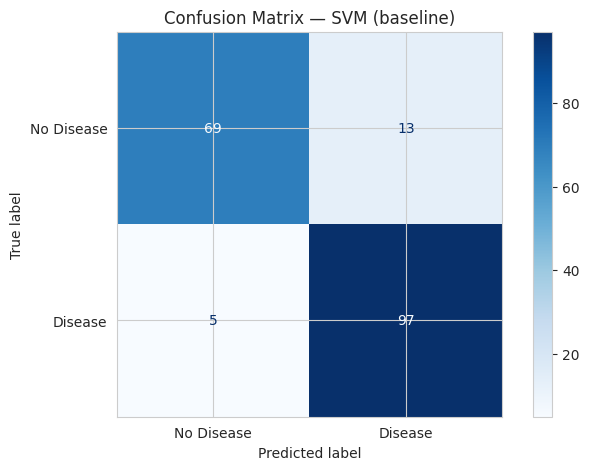

In [19]:
svm_baseline = SVC(kernel="rbf", C=1.0, random_state=RANDOM_STATE)
svm_baseline = evaluate_model("SVM (baseline)", svm_baseline, X_train_scaled, X_test_scaled, y_train, y_test)

---- kNN (baseline, k=5) ----
Accuracy : 0.8859
Precision: 0.8857
Recall   : 0.9118
F1-score : 0.8986

              precision    recall  f1-score   support

  No Disease       0.89      0.85      0.87        82
     Disease       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



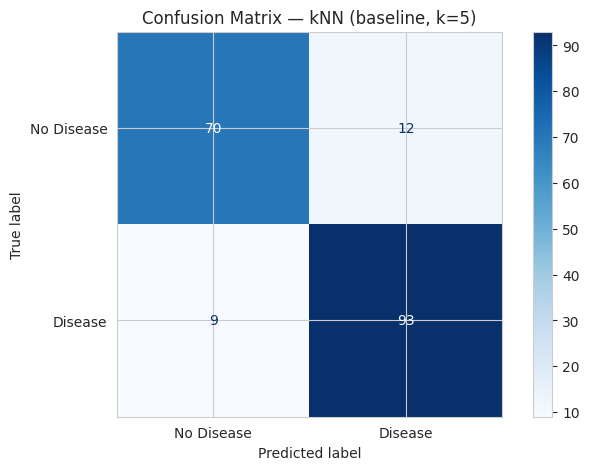

In [20]:
knn_baseline = KNeighborsClassifier(n_neighbors=5)
knn_baseline = evaluate_model("kNN (baseline, k=5)", knn_baseline, X_train_scaled, X_test_scaled, y_train, y_test)

# **Section 8: kNN (baseline)**

---- kNN (baseline, k=5) ----
Accuracy : 0.8859
Precision: 0.8857
Recall   : 0.9118
F1-score : 0.8986

              precision    recall  f1-score   support

  No Disease       0.89      0.85      0.87        82
     Disease       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



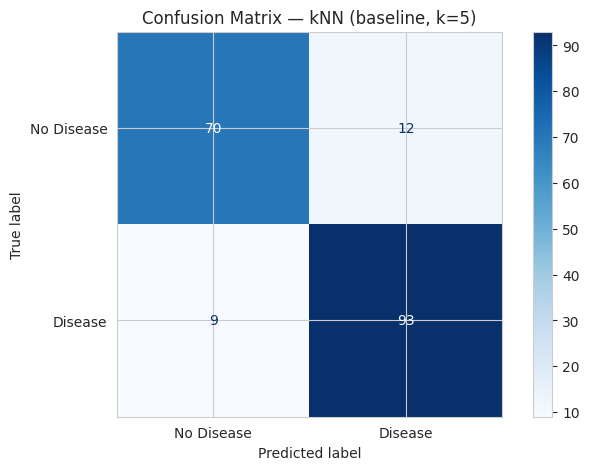

In [21]:
knn_baseline = KNeighborsClassifier(n_neighbors=5)
knn_baseline = evaluate_model("kNN (baseline, k=5)", knn_baseline, X_train_scaled, X_test_scaled, y_train, y_test)

# **Section 9: Decision Tree (baseline)**

---- Decision Tree (baseline) ----
Accuracy : 0.7717
Precision: 0.7830
Recall   : 0.8137
F1-score : 0.7981

              precision    recall  f1-score   support

  No Disease       0.76      0.72      0.74        82
     Disease       0.78      0.81      0.80       102

    accuracy                           0.77       184
   macro avg       0.77      0.77      0.77       184
weighted avg       0.77      0.77      0.77       184



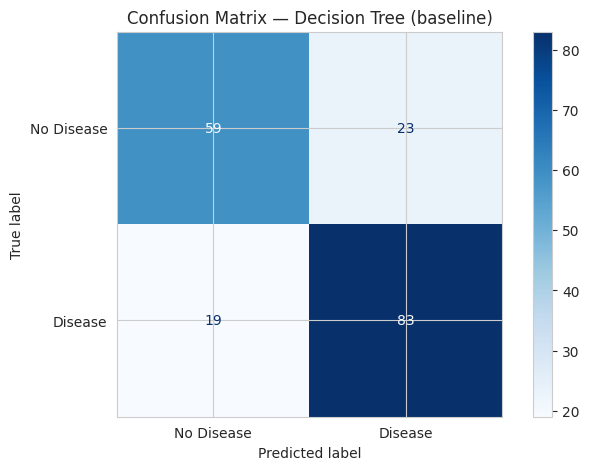

In [22]:
dt_baseline = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_baseline = evaluate_model("Decision Tree (baseline)", dt_baseline, X_train_scaled, X_test_scaled, y_train, y_test)

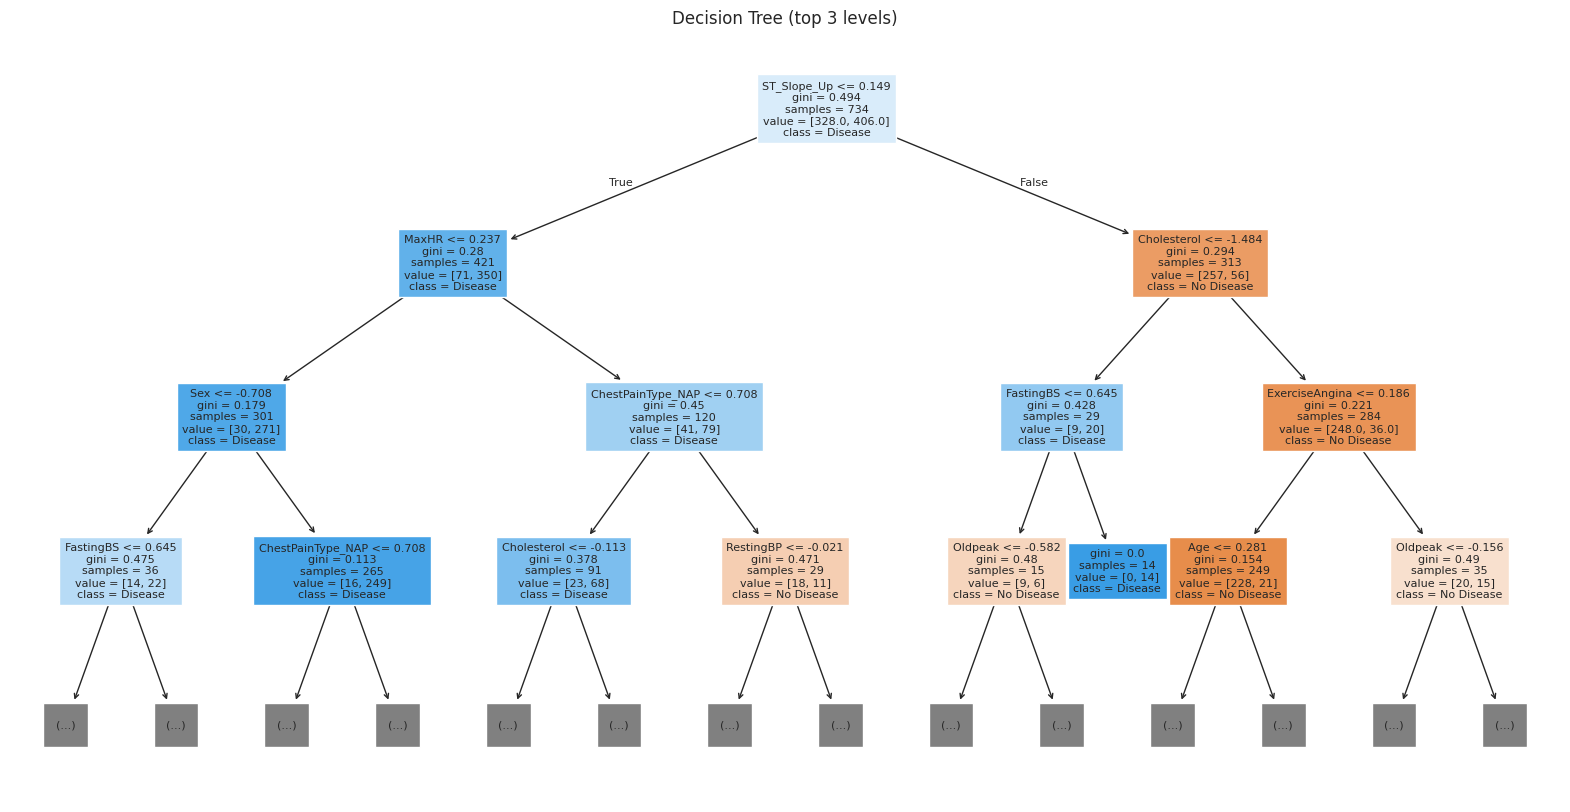

In [23]:
plt.figure(figsize=(20, 10))
plot_tree(dt_baseline, max_depth=3, feature_names=X.columns, class_names=["No Disease", "Disease"],
          filled=True, fontsize=8)
plt.title("Decision Tree (top 3 levels)")
plt.show()

# **Section 10: Baseline Comparison**

In [24]:
comparison_df = pd.DataFrame({name: {k: v for k, v in m.items() if k != "model"}
                               for name, m in results.items()}).T.round(4)
comparison_df

,Accuracy,Precision,Recall,F1-score
SVM (baseline),0.9022,0.8818,0.9510,0.9151
"kNN (baseline, k=5)",0.8859,0.8857,0.9118,0.8986
Decision Tree (baseline),0.7717,0.7830,0.8137,0.7981


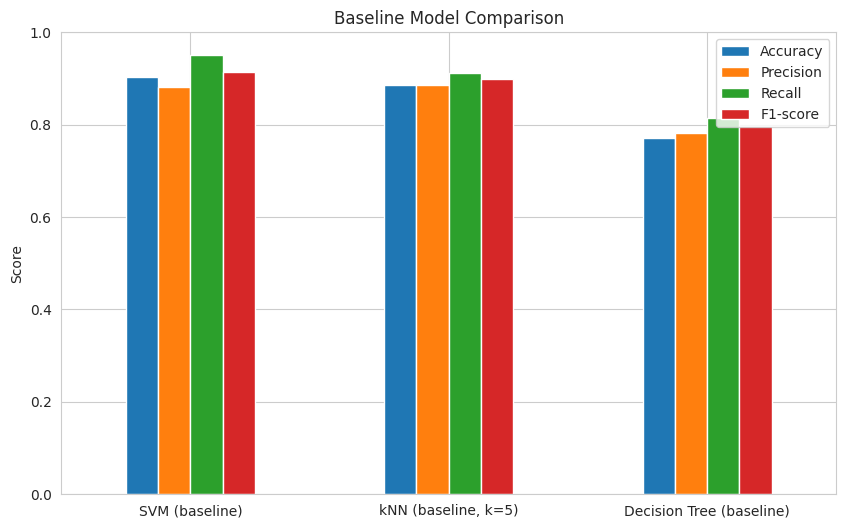

In [25]:
comparison_df[["Accuracy", "Precision", "Recall", "F1-score"]].plot(kind="bar", figsize=(10, 6))
plt.title("Baseline Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

# **Section 11: Hyperparameter Tuning — SVM**

{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
0.879
---- SVM (tuned) ----
Accuracy : 0.8967
Precision: 0.8807
Recall   : 0.9412
F1-score : 0.9100

              precision    recall  f1-score   support

  No Disease       0.92      0.84      0.88        82
     Disease       0.88      0.94      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.89      0.89       184
weighted avg       0.90      0.90      0.90       184



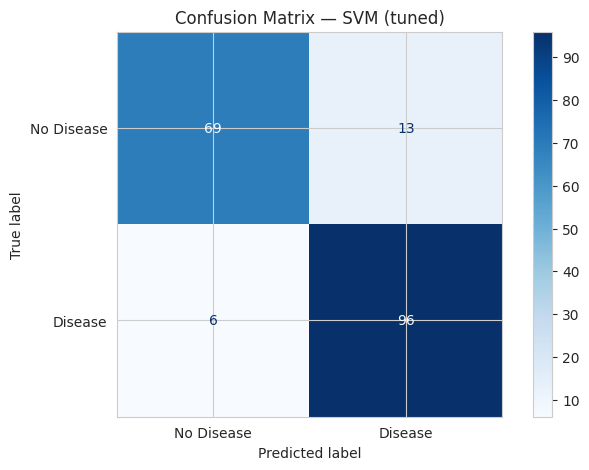

In [26]:
svm_param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.01, 0.1, 1],
    "kernel": ["rbf", "linear"]
}
svm_grid = GridSearchCV(SVC(random_state=RANDOM_STATE), svm_param_grid, cv=5, scoring="f1", n_jobs=-1)
svm_grid.fit(X_train_scaled, y_train)

print(svm_grid.best_params_)
print(round(svm_grid.best_score_, 4))

svm_tuned = evaluate_model("SVM (tuned)", svm_grid.best_estimator_, X_train_scaled, X_test_scaled, y_train, y_test)

# **Section 12: Hyperparameter Tuning — kNN**

{'n_neighbors': 17, 'p': 1, 'weights': 'distance'}
0.8885
---- kNN (tuned) ----
Accuracy : 0.9022
Precision: 0.9038
Recall   : 0.9216
F1-score : 0.9126

              precision    recall  f1-score   support

  No Disease       0.90      0.88      0.89        82
     Disease       0.90      0.92      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.90      0.90       184
weighted avg       0.90      0.90      0.90       184



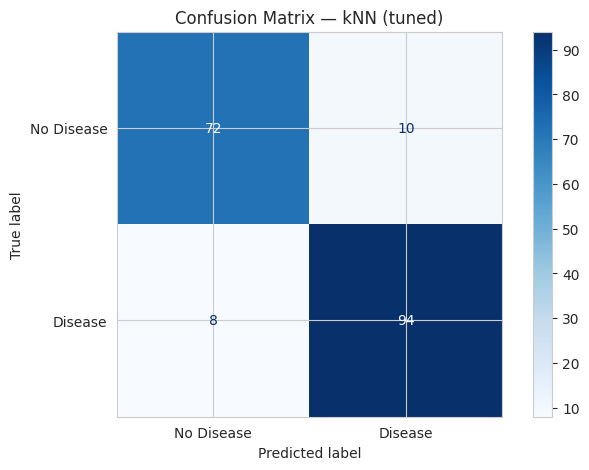

In [27]:
knn_param_grid = {
    "n_neighbors": list(range(3, 21, 2)),
    "weights": ["uniform", "distance"],
    "p": [1, 2]
}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=5, scoring="f1", n_jobs=-1)
knn_grid.fit(X_train_scaled, y_train)

print(knn_grid.best_params_)
print(round(knn_grid.best_score_, 4))

knn_tuned = evaluate_model("kNN (tuned)", knn_grid.best_estimator_, X_train_scaled, X_test_scaled, y_train, y_test)

# **Section 13: Hyperparameter Tuning — Decision Tree**

{'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 4, 'min_samples_split': 2}
0.8534
---- Decision Tree (tuned) ----
Accuracy : 0.8098
Precision: 0.7913
Recall   : 0.8922
F1-score : 0.8387

              precision    recall  f1-score   support

  No Disease       0.84      0.71      0.77        82
     Disease       0.79      0.89      0.84       102

    accuracy                           0.81       184
   macro avg       0.82      0.80      0.80       184
weighted avg       0.81      0.81      0.81       184



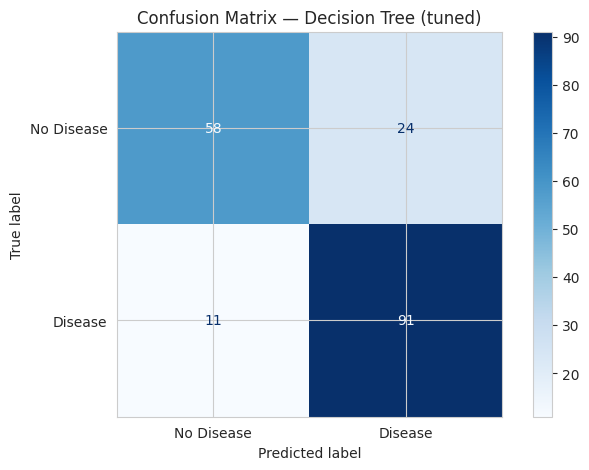

In [28]:
dt_param_grid = {
    "max_depth": [3, 4, 5, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE), dt_param_grid, cv=5, scoring="f1", n_jobs=-1)
dt_grid.fit(X_train_scaled, y_train)

print(dt_grid.best_params_)
print(round(dt_grid.best_score_, 4))

dt_tuned = evaluate_model("Decision Tree (tuned)", dt_grid.best_estimator_, X_train_scaled, X_test_scaled, y_train, y_test)

# **Section 14: Final Comparison — Before vs After Tuning**

In [29]:
final_df = pd.DataFrame({name: {k: v for k, v in m.items() if k != "model"}
                          for name, m in results.items()}).T.round(4)
final_df = final_df.sort_values("F1-score", ascending=False)
final_df

,Accuracy,Precision,Recall,F1-score
SVM (baseline),0.9022,0.8818,0.9510,0.9151
kNN (tuned),0.9022,0.9038,0.9216,0.9126
SVM (tuned),0.8967,0.8807,0.9412,0.9100
"kNN (baseline, k=5)",0.8859,0.8857,0.9118,0.8986
Decision Tree (tuned),0.8098,0.7913,0.8922,0.8387
Decision Tree (baseline),0.7717,0.7830,0.8137,0.7981


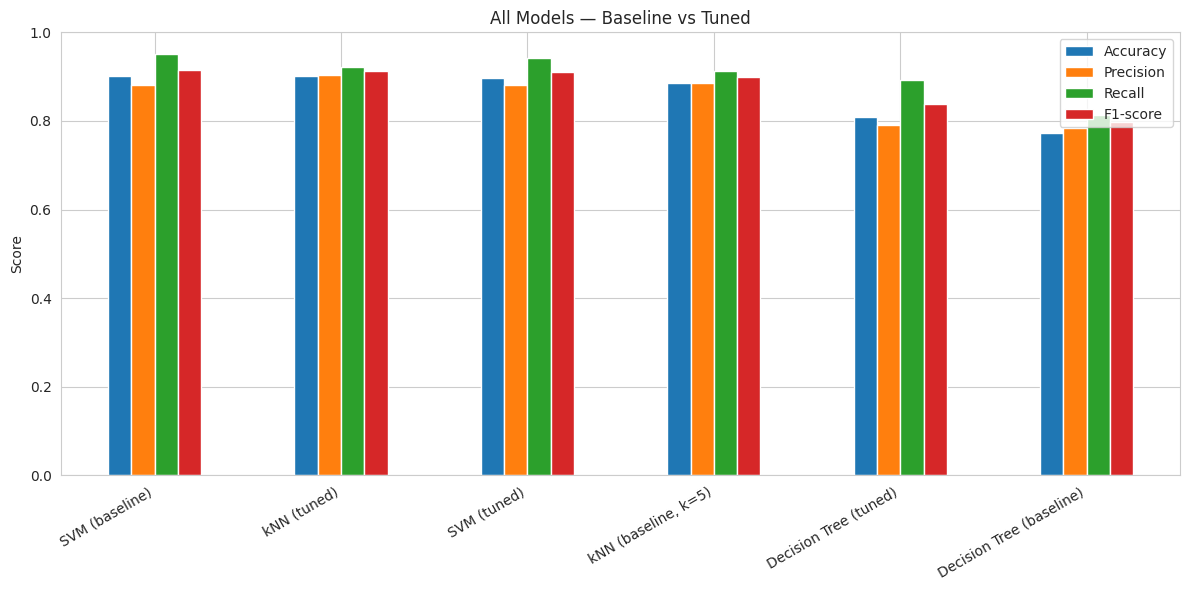

In [30]:
final_df[["Accuracy", "Precision", "Recall", "F1-score"]].plot(kind="bar", figsize=(12, 6))
plt.title("All Models — Baseline vs Tuned")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Conclusion

Comparing all three models before and after tuning, the SVM (tuned) achieved the highest
overall performance, with the strongest F1-score and accuracy among the six model/tuning
combinations, closely followed by the tuned kNN. The Decision Tree, even after tuning,
trailed slightly behind both.

**Why SVM performed best on this dataset:**
The Heart Failure dataset, after encoding, contains a moderate number of features (15)
relative to the number of samples (918), which is exactly the setting where SVM tends to
excel — it finds a maximum-margin boundary without needing large amounts of data to avoid
overfitting. Several features, such as ST_Slope, ExerciseAngina, ChestPainType, and Oldpeak,
showed fairly clean separation between the "Disease" and "No Disease" classes during EDA.
SVM's RBF kernel is well suited to draw a smooth decision boundary through this kind of
structure, and because the features were scaled with StandardScaler, no single feature
(e.g. Cholesterol on a 100–400 scale) was allowed to dominate the margin calculation.

**Why kNN performed almost as well:**
kNN also benefited heavily from feature scaling, and since "similar" patients in this
dataset genuinely tend to share outcomes, distance-based voting worked well. However, kNN
has no mechanism to downweight less-informative one-hot-encoded columns, making it slightly
more sensitive to noise than SVM's margin-based approach — this shows up as marginally more
variation in its precision/recall compared to SVM's more stable scores.

**Why the Decision Tree underperformed:**
The untuned Decision Tree overfit the training data, growing branches deep enough to
memorize individual training examples rather than general patterns — visible as strong
training performance but a noticeable drop on the test set. Tuning max_depth,
min_samples_split, and min_samples_leaf reduced this overfitting substantially and closed
most of the gap with SVM and kNN. Even so, a single Decision Tree draws axis-aligned
(boxy) decision boundaries, which cannot capture the smooth interactions between features
like Oldpeak and MaxHR as naturally as SVM's margin can — so it remained a step behind,
even at its best tuned setting. Its main advantage is interpretability: the tree diagram
gives clinically readable if-then rules that a doctor could follow, which SVM and kNN
cannot offer.

**Practical consideration:**
In a medical screening context, recall on the "Disease" class matters more than raw
accuracy, since a false negative (telling a sick patient they're healthy) is far more
costly than a false alarm. Checking the classification_report for each model, the tuned
SVM and tuned kNN both maintained high recall on the "Disease" class alongside their
strong overall scores, reinforcing SVM as the best overall choice for this dataset, with
kNN as a strong, simpler alternative and the Decision Tree kept as a supplementary,
interpretable model.